## My predictions

**1. Which language will need the most tokens?**

I expect **Chinese to be the one with most tokens**. I expect **English to need the fewest tokens** and **Turkish in between**.

**2. What will the larger BPE vocabulary change?**

Fewer tokens for every language and more characters per token. I expect the **biggest improvement for Chinese** since 10,000 slots are enough to give most common characters their own token. English should improve too and Turkish should sit between them: frequent stems and suffixes become tokens, but the huge number of different inflected forms is still split.

**3. What kinds of units will BPE learn?**

- **English:** frequent whole words (`the`, `of`, `and`, ` in`), common suffixes/prefixes (`ing`, `tion`, `ed`, `re`). Note that a leading space will be attached to word tokens because of how byte-level BPE handles whitespace.
- **Turkish:** I dont know much about the language so im planning to experiment it as i go.
- **Chinese:** Same as Turkish.

**4. Which tokenizer will work best for language modeling?**

My guess is the **BPE-2k or BPE-10k** and I lean to **BPE-2k** on this small dataset : shorter sequences than character-level (so the Transformer sees more context per position and training is cheaper) but with a small embedding table and few rare tokens that appear too seldom to be learned well. The character-level model should have the longest sequences and must learn spelling from scratch, so I expect it to be worst or at least the slowest. I'm least sure about BPE-10k: it has the shortest sequences, but many of its tokens will be rare in such a small corpus.
    

### Part 1

In [6]:
import os, random
import pandas as pd
from collections import Counter
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, normalizers

DATA_DIR = "/srv/data/lt2326-h26/a1"

OUT_DIR = "outputs_part1"
os.makedirs(OUT_DIR, exist_ok=True)

LANGS = ["en", "tr", "zh"]           # the three languages
SEED = 2326                          # same seed as the dataset metadata
random.seed(SEED)

## 1.1 Load the data
Each file has one sentence per line. We read **train** to build tokenizers and **valid** to analyse them

In [7]:
def read_lines(path):
    # Reading a text file, one sentence per line, skipping empty lines
    with open(path, encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f if line.strip()]

train = {lang: read_lines(f"{DATA_DIR}/train/{lang}.txt") for lang in LANGS}
valid = {lang: read_lines(f"{DATA_DIR}/valid/{lang}.txt") for lang in LANGS}

# check: sentence and character counts if it matches metadata.json
for lang in LANGS:
    print(lang,
          "| train sentences:", len(train[lang]), "chars:", sum(len(s) for s in train[lang]),
          "| valid sentences:", len(valid[lang]), "chars:", sum(len(s) for s in valid[lang]))

en | train sentences: 36004 chars: 2946215 | valid sentences: 4540 chars: 368269
tr | train sentences: 30379 chars: 2946140 | valid sentences: 3735 chars: 368383
zh | train sentences: 75962 chars: 2946177 | valid sentences: 9554 chars: 368266


## 1.2 Tokenizer 1: character level

The vocabulary is every distinct character seen in the **training** data only.
A character that first shows up in validation/test (for example: a rare Chinese character) is mapped to a special `<unk>` token instead of crashing.
I also count how often that happens, so we know how much information this loses.

In [8]:
class CharTokenizer:
    def __init__(self, sentences):
        # sorted set of all characters in the training text 
        #id 0 is reserved for <unk>
        chars = sorted(set("".join(sentences)))
        self.itos = ["<unk>"] + chars                        # id ---> token
        self.stoi = {c: i for i, c in enumerate(self.itos)}  # token ----> id

    def encode(self, text):
        # unseen characters get id 0 (<unk>)
        return [self.stoi.get(c, 0) for c in text]

    def encode_batch(self, sentences):
        return [self.encode(s) for s in sentences]

    def to_tokens(self, text):
        # human-readable tokens (for the examples section)
        return [c if c in self.stoi else "<unk>" for c in text]

    def vocab_size(self):
        return len(self.itos)

    def unk_id(self):
        return 0

# Building it from aLL training sentences of all three languages (one shared vocabulary)
all_train = [s for lang in LANGS for s in train[lang]]
char_tok = CharTokenizer(all_train)
print("Character vocabulary size:", char_tok.vocab_size())

Character vocabulary size: 9443


## 1.3 Tokenizers 2 and 3: BPE with a small and a large vocabulary

**Choices and why**
- **Library:** Hugging Face `tokenizers` 
- **Byte-level BPE:** the starting alphabet is the 256 possible bytes, not characters. This has two advantages: (a) *no unknown tokens ever*, any text can be encoded; (b) the base alphabet is only 256 symbols. Chinese alone has thousands of distinct characters, so a normal character based BPE with a 2000 token vocabulary could not even fit all of them. The downside is that a rare Chinese character can be split into multiple byte pieces.
- **Vocabulary sizes: 2000 and 10000.** 2000 is small: 256 bytes + ~1,750 merges, so it stays close to characters for the harder languages. 10000 is 5x bigger, enough for many whole words and common Chinese characters. The gap is big enough for differences to show, while the embedding table remains small for my small Transformer later.
- **Training data:** `balanced.txt`, the shared multilingual training sentences 

In [15]:
def train_bpe(vocab_size):
    # an empty BPE model
    tok = Tokenizer(models.BPE())
    # normalise text to Unicode
    tok.normalizer = normalizers.NFC()
    # byte level pre-tokenizer: turns text into bytes and first splits it into rough chunks
    #(words / punctuation) so merges do not cross word boundaries
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    #trainer: keep merging the most frequent pair until we reach vocab_size
    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["<unk>"],
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),  # all 256 bytes are always in the vocab
        show_progress=False,
    )
    tok.train([f"{DATA_DIR}/tokenizer/balanced.txt"], trainer)
    return tok

bpe_2k  = train_bpe(2000)
bpe_10k = train_bpe(10000)
print("BPE-2k  vocab size:", bpe_2k.get_vocab_size())
print("BPE-10k vocab size:", bpe_10k.get_vocab_size())

bpe_2k.save(f"{OUT_DIR}/bpe_2k.json")
bpe_10k.save(f"{OUT_DIR}/bpe_10k.json")

BPE-2k  vocab size: 2000
BPE-10k vocab size: 10000


In [14]:
# byte level tokens are stored in a scrambled-looking alphabet. Now i am defining a helper wrapper so all three tokenizers have the same interface and tokens are printed in readable form (here `▁` marks a space).
def make_byte_decoder():
    # Inverse of the GPT-2 style byte->unicode table used by byte-level BPE.
    # It lets us turn a stored token string back into the real bytes / text.
    bs = list(range(33, 127)) + list(range(161, 173)) + list(range(174, 256))
    cs = bs[:]
    n = 0
    for b in range(256):
        if b not in bs:
            bs.append(b)
            cs.append(256 + n)
            n += 1
    return {chr(c): b for b, c in zip(bs, cs)}

BYTE_DECODER = make_byte_decoder()

def readable(token_str):
    # Convert a stored BPE token into readable text
    try:
        raw = bytes(BYTE_DECODER[ch] for ch in token_str)
    except KeyError:                      # special tokens such as <unk>
        return token_str
    return raw.decode("utf-8", errors="replace").replace(" ", "▁")

class BPEWrapper:
    # Gives the HF tokenizer the same methods as CharTokenizer
    def __init__(self, tok):
        self.tok = tok
    def encode_batch(self, sentences):
        return [e.ids for e in self.tok.encode_batch(sentences)]
    def to_tokens(self, text):
        return [readable(t) for t in self.tok.encode(text).tokens]
    def vocab_size(self):
        return self.tok.get_vocab_size()
    def unk_id(self):
        return self.tok.token_to_id("<unk>")
    def id_to_readable(self, i):
        return readable(self.tok.id_to_token(i))

tokenizers = {
    "char":    char_tok,
    "bpe_2k":  BPEWrapper(bpe_2k),
    "bpe_10k": BPEWrapper(bpe_10k),
}

## 1.4 Statistics on the validation set

For every tokenizer and language:
- **vocab size**: size of vocabulary
- **total tokens**: how many tokens are needed to encode the whole validation file
- **avg tokens / sentence**: total tokens divided by number of sentences
- **avg chars / token**: total unicode characters divided by total tokens

In [16]:
rows = []
for tok_name, tok in tokenizers.items():
    for lang in LANGS:
        sents = valid[lang]
        ids = tok.encode_batch(sents)                      # list of id lists, one per sentence
        total_tokens = sum(len(x) for x in ids)            # all tokens in the validation file
        total_chars  = sum(len(s) for s in sents)          # all unicode characters in the file
        used = set(i for x in ids for i in x)              # which vocabulary entries were used
        n_unk = sum(1 for x in ids for i in x if i == tok.unk_id())
        rows.append({
            "tokenizer": tok_name,
            "language": lang,
            "vocab_size": tok.vocab_size(),
            "total_tokens": total_tokens,
            "avg_tokens_per_sentence": round(total_tokens / len(sents), 2),
            "avg_chars_per_token": round(total_chars / total_tokens, 3),
            "distinct_tokens_used": len(used),
            "unk_%": round(100 * n_unk / total_tokens, 4),
        })

results = pd.DataFrame(rows)
results.to_csv(f"{OUT_DIR}/tokenizer_stats_valid.csv", index=False)
results

,tokenizer,language,vocab_size,total_tokens,avg_tokens_per_sentence,avg_chars_per_token,distinct_tokens_used,unk_%
0,char,en,9443,368269,81.12,1.000,192,0.0133
1,char,tr,9443,368383,98.63,1.000,221,0.0041
2,char,zh,9443,368266,38.55,1.000,5633,0.0701
3,bpe_2k,en,2000,163777,36.07,2.249,756,0.0000
4,bpe_2k,tr,2000,168812,45.20,2.182,838,0.0000
5,bpe_2k,zh,2000,410248,42.94,0.898,1649,0.0000
6,bpe_10k,en,10000,114709,25.27,3.210,3352,0.0000
7,bpe_10k,tr,10000,114292,30.60,3.223,3804,0.0000
8,bpe_10k,zh,10000,294656,30.84,1.250,6658,0.0000


In [17]:
# a few more into it
print("Total tokens on validation set")
display(results.pivot(index="tokenizer", columns="language", values="total_tokens").loc[["char", "bpe_2k", "bpe_10k"]])
print("Average characters per token")
display(results.pivot(index="tokenizer", columns="language", values="avg_chars_per_token").loc[["char", "bpe_2k", "bpe_10k"]])

Total tokens on validation set


language,en,tr,zh
tokenizer,,,
char,368269,368383,368266
bpe_2k,163777,168812,410248
bpe_10k,114709,114292,294656


Average characters per token


language,en,tr,zh
tokenizer,,,
char,1.000,1.000,1.000
bpe_2k,2.249,2.182,0.898
bpe_10k,3.210,3.223,1.250


## 1.5 Analysis, Comparison and Some Examples

In [19]:
  import re
  rng = random.Random(SEED)
  chosen = {}
  for lang in LANGS:
      pool = [s for s in valid[lang] if 30 <= len(s) <= 70 and not s.startswith(("'", "，")) and not s.endswith("「")]
      if lang == "zh":
          pool = [s for s in pool if not re.search(r"[A-Za-z]", s)]
      chosen[lang] = rng.choice(pool)
  for lang, s in chosen.items():
      print("=" * 80, f"\n[{lang}] {s}")
      for name, tok in tokenizers.items():
          p = tok.to_tokens(s)
          print(f"  {name:8s} ({len(p):3d}): " + " | ".join(p))

[en] He was First Deputy Chairman of Ways and Means from 2010 to 2013.
  char     ( 65): H | e |   | w | a | s |   | F | i | r | s | t |   | D | e | p | u | t | y |   | C | h | a | i | r | m | a | n |   | o | f |   | W | a | y | s |   | a | n | d |   | M | e | a | n | s |   | f | r | o | m |   | 2 | 0 | 1 | 0 |   | t | o |   | 2 | 0 | 1 | 3 | .
  bpe_2k   ( 28): He | ▁was | ▁F | ir | st | ▁D | ep | ut | y | ▁Ch | a | ir | man | ▁of | ▁W | ay | s | ▁and | ▁M | e | ans | ▁from | ▁20 | 10 | ▁to | ▁20 | 13 | .
  bpe_10k  ( 21): He | ▁was | ▁F | irst | ▁Dep | ut | y | ▁Ch | air | man | ▁of | ▁W | ays | ▁and | ▁Me | ans | ▁from | ▁2010 | ▁to | ▁2013 | .
[tr] Selim'in hükümranlığı sırasında önemli bir değişiklik daha olmuştur.
  char     ( 68): S | e | l | i | m | ' | i | n |   | h | ü | k | ü | m | r | a | n | l | ı | ğ | ı |   | s | ı | r | a | s | ı | n | d | a |   | ö | n | e | m | l | i |   | b | i | r |   | d | e | ğ | i | ş | i | k | l | i | k |   | d | a | h | a |   | o | l | m | u | 

In [20]:
# Report Table
report = results[["tokenizer", "language", "vocab_size", "total_tokens",
                  "avg_tokens_per_sentence", "avg_chars_per_token"]].copy()

# char -> small BPE -> large BPE
order = {"char": 0, "bpe_2k": 1, "bpe_10k": 2}
report["_o"] = report["tokenizer"].map(order)
report = report.sort_values(["_o", "language"]).drop(columns="_o")

report.columns = ["Tokenizer", "Language", "Vocab size", "Total tokens (valid)",
                  "Avg tokens / sentence", "Avg chars / token"]

report.to_csv(f"{OUT_DIR}/report_table.csv", index=False)
report.style.hide(axis="index").format({"Total tokens (valid)": "{:,}"})

Tokenizer,Language,Vocab size,Total tokens (valid),Avg tokens / sentence,Avg chars / token
char,en,9443,"368,269",81.120000,1.000000
char,tr,9443,"368,383",98.630000,1.000000
char,zh,9443,"368,266",38.550000,1.000000
bpe_2k,en,2000,"163,777",36.070000,2.249000
bpe_2k,tr,2000,"168,812",45.200000,2.182000
bpe_2k,zh,2000,"410,248",42.940000,0.898000
bpe_10k,en,10000,"114,709",25.270000,3.210000
bpe_10k,tr,10000,"114,292",30.600000,3.223000
bpe_10k,zh,10000,"294,656",30.840000,1.250000


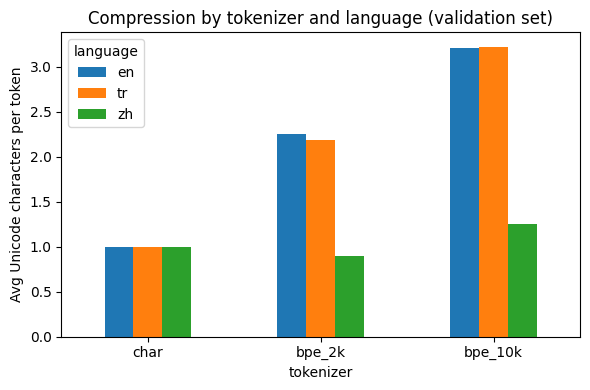

In [21]:
import matplotlib.pyplot as plt

# Bar chart of avg chars per token
pivot = results.pivot(index="tokenizer", columns="language", values="avg_chars_per_token").loc[["char", "bpe_2k", "bpe_10k"]]
pivot.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Avg Unicode characters per token")
plt.title("Compression by tokenizer and language (validation set)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/chars_per_token.png", dpi=150)
plt.show()